# Soybean Yield Prediction Pipeline
**Google Colab — Full Pipeline**

This notebook covers:
1. **Setup & Data Upload** — install libraries, mount Drive, upload dataset
2. **Data Cleaning** — drop duplicates, outliers, impute missing values
3. **Feature Engineering** — weather aggregates, soil features, interactions
4. **Export** — save cleaned + engineered CSV
5. **K-Means Clustering** — unsupervised county profiling
6. **Model Training** — Linear → Ridge → Lasso → Random Forest → XGBoost
7. **Evaluation & Comparison** — RMSE, MAE, R² across all models
8. **Feature Importance** — top drivers of soybean yield

---
**Dataset:** `khaki_multi_crop_yield.csv`  
**Target:** `soybean_yield` (Bu/Acre)

## STEP 0 — Setup: Install Libraries & Import

In [ ]:
# Install XGBoost (pre-installed on Colab but ensuring latest)
!pip install xgboost --quiet

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
pd.set_option('display.max_columns', 20)

print(' All libraries imported successfully.')

 All libraries imported successfully.


## STEP 1 — Load Data

**Option A:** Upload directly from your computer  
**Option B:** Mount Google Drive (if the CSV is already there)

In [ ]:
# ── OPTION A: Upload from local computer ──────────────────────
from google.colab import files
print('Please upload khaki_multi_crop_yield.csv')
uploaded = files.upload()
RAW_PATH = list(uploaded.keys())[0]
print(f'Uploaded: {RAW_PATH}')

Please upload khaki_multi_crop_yield.csv


Saving khaki_multi_crop_yield.csv to khaki_multi_crop_yield (1).csv
Uploaded: khaki_multi_crop_yield (1).csv


In [ ]:
# ── OPTION B: Mount Google Drive (comment out Option A above if using this) ─
# from google.colab import drive
# drive.mount('/content/drive')
# RAW_PATH = '/content/drive/MyDrive/YOUR_FOLDER/khaki_multi_crop_yield.csv'

OUTPUT_PATH = '/content/soybean_yield_cleaned_engineered.csv'

In [ ]:
# Column name maps
WEATHER_VAR_NAMES = {
    1: 'precipitation',
    2: 'solar_radiation',
    3: 'snow_water_equivalent',
    4: 'maximum_temperature',
    5: 'minimum_temperature',
    6: 'vapor_pressure',
}

PRACTICE_NAMES = {
    'P_1' : 'soybean_area_planted_acres',
    'P_2' : 'soybean_area_harvested_acres',
    'P_3' : 'soybean_production_bushels',
    'P_4' : 'corn_area_planted_acres',
    'P_5' : 'corn_area_harvested_acres',
    'P_6' : 'corn_production_bushels',
    'P_7' : 'total_cropland_acres',
    'P_8' : 'irrigated_harvested_cropland_acres',
    'P_9' : 'fertilizer_expense_dollars',
    'P_10': 'chemical_expense_dollars',
    'P_11': 'seed_cost_per_acre_dollars',
    'P_12': 'labor_expense_dollars',
    'P_13': 'fuel_and_oil_expense_dollars',
    'P_14': 'machinery_and_equipment_expense_dollars',
}

SOIL_PROPERTY_NAMES = {
    'bdod'   : 'bulk_density_of_fine_earth',
    'cec'    : 'cation_exchange_capacity',
    'cfvo'   : 'coarse_fragments_volume_fraction',
    'clay'   : 'clay_content',
    'nitrogen': 'total_nitrogen',
    'ocd'    : 'organic_carbon_density',
    'ocs'    : 'organic_carbon_stocks',
    'phh2o'  : 'soil_ph_in_water',
    'sand'   : 'sand_content',
    'silt'   : 'silt_content',
    'soc'    : 'soil_organic_carbon',
}

GROWING_SEASON_WEEKS = list(range(14, 40))  # weeks 14–39 (May–Sep)

# ── Load ─────────────────────────────────────────────────────
print('=' * 65)
print('STEP 1 — Loading raw data')
print('=' * 65)

raw = pd.read_csv(RAW_PATH)
print(f'  Raw shape: {raw.shape}')
raw.head(3)

STEP 1 — Loading raw data
  Raw shape: (25306, 401)


,State,County,year,lat,lng,loc_ID,soybean_yield,corn_yield,winter_wheat_yield,W_1_1,...,P_5,P_6,P_7,P_8,P_9,P_10,P_11,P_12,P_13,P_14
0,illinois,cook,1980,41.8401,-87.8168,15,32.5,98.0,NaN,1.221429,...,22.0,22.0,0.0,23.0,3.0,0.0,0.0,0.0,0,0
1,illinois,cook,1981,41.8401,-87.8168,15,34.0,117.0,NaN,0.164286,...,1.0,13.0,15.0,27.0,15.0,10.0,6.0,4.0,0,0
2,illinois,cook,1982,41.8401,-87.8168,15,32.0,121.0,NaN,4.878571,...,22.0,13.0,2.0,8.0,5.0,3.0,1.0,1.0,0,0


## STEP 2 — Data Cleaning

In [ ]:
print('=' * 65)
print('STEP 2 — Data Cleaning')
print('=' * 65)

df = raw.copy()

# 2-a  Drop non-target yield columns
print('  [2a] Dropping corn_yield and winter_wheat_yield …')
df = df.drop(columns=['corn_yield', 'winter_wheat_yield'], errors='ignore')

# 2-b  Drop rows with missing target
before = len(df)
df = df.dropna(subset=['soybean_yield'])
print(f'  [2b] Dropped {before - len(df)} rows with missing soybean_yield. Remaining: {len(df)}')

# 2-c  Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f'  [2c] Dropped {before - len(df)} exact duplicate rows.')

# 2-d  Standardise State & County strings
df['State']  = df['State'].str.strip().str.title()
df['County'] = df['County'].str.strip().str.title()
print('  [2d] Standardised State / County casing.')

# 2-e  Outlier removal on soybean_yield using IQR (per-state, factor=3)
def iqr_outlier_mask(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series >= q1 - factor * iqr) & (series <= q3 + factor * iqr)

before = len(df)
mask = df.groupby('State')['soybean_yield'].transform(iqr_outlier_mask)
df = df[mask].copy()
print(f'  [2e] Removed {before - len(df)} extreme yield outliers (IQR ×3 per state). Remaining: {len(df)}')

# 2-f  Clip soybean_yield to physically reasonable range
before = len(df)
df = df[(df['soybean_yield'] >= 5) & (df['soybean_yield'] <= 100)]
print(f'  [2f] Clipped to [5, 100] Bu/Acre; removed {before - len(df)} additional rows. Remaining: {len(df)}')

# 2-g  Impute missing weather values with column median
weather_cols = [c for c in df.columns if c.startswith('W_')]
missing_weather = df[weather_cols].isnull().sum().sum()
if missing_weather > 0:
    df[weather_cols] = df[weather_cols].fillna(df[weather_cols].median())
    print(f'  [2g] Imputed {missing_weather} missing weather values with column median.')
else:
    print('  [2g] No missing weather values found.')

# 2-h  Impute missing soil values with column median
soil_cols = [c for c in df.columns if any(c.startswith(s) for s in SOIL_PROPERTY_NAMES)]
missing_soil = df[soil_cols].isnull().sum().sum()
if missing_soil > 0:
    df[soil_cols] = df[soil_cols].fillna(df[soil_cols].median())
    print(f'  [2h] Imputed {missing_soil} missing soil values with column median.')
else:
    print('  [2h] No missing soil values found.')

# 2-i  Impute missing practice values with 0
practice_cols = [c for c in df.columns if c.startswith('P_')]
missing_practice = df[practice_cols].isnull().sum().sum()
if missing_practice > 0:
    df[practice_cols] = df[practice_cols].fillna(0)
    print(f'  [2i] Imputed {missing_practice} missing practice values with 0.')
else:
    print('  [2i] No missing practice values found.')

# 2-j  Drop loc_ID
if 'loc_ID' in df.columns:
    df = df.drop(columns=['loc_ID'])
    print('  [2j] Dropped loc_ID (redundant identifier).')

print(f'\n  ✓ Clean dataset shape: {df.shape}')

STEP 2 — Data Cleaning
  [2a] Dropping corn_yield and winter_wheat_yield …
  [2b] Dropped 0 rows with missing soybean_yield. Remaining: 25306
  [2c] Dropped 0 exact duplicate rows.
  [2d] Standardised State / County casing.
  [2e] Removed 0 extreme yield outliers (IQR ×3 per state). Remaining: 25306
  [2f] Clipped to [5, 100] Bu/Acre; removed 2 additional rows. Remaining: 25304
  [2g] No missing weather values found.
  [2h] No missing soil values found.
  [2i] No missing practice values found.
  [2j] Dropped loc_ID (redundant identifier).

  ✓ Clean dataset shape: (25304, 398)


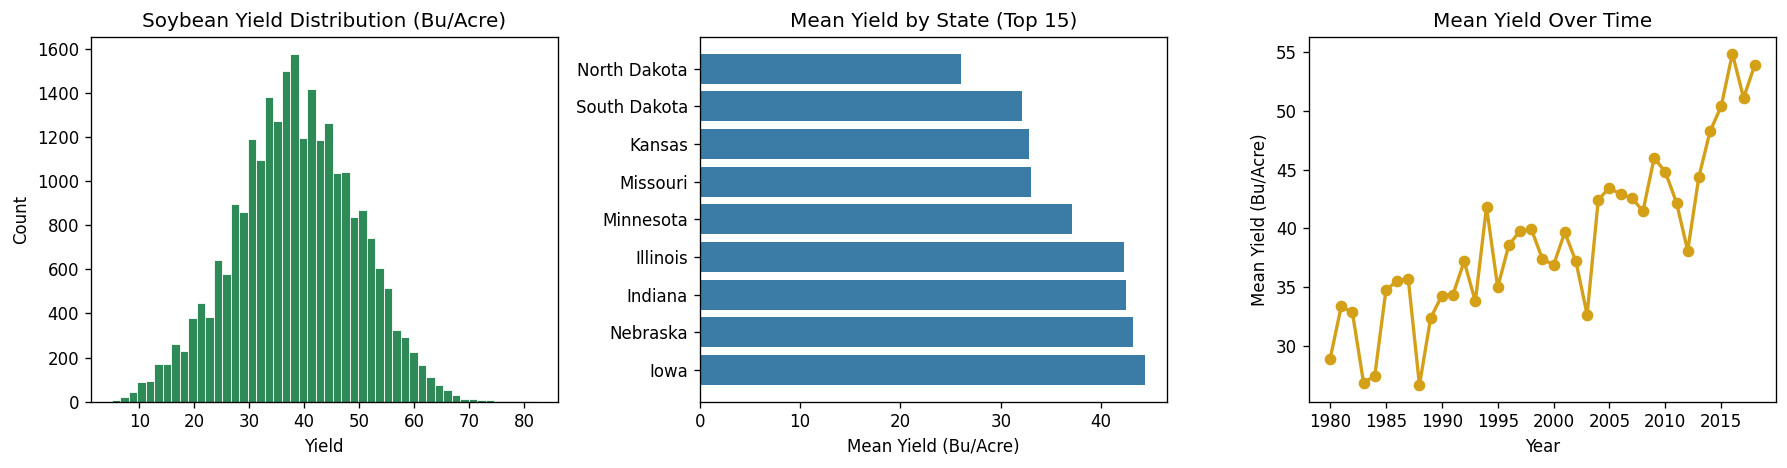

 EDA plot saved.


In [ ]:
# ── Quick EDA on cleaned data ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['soybean_yield'], bins=50, color='#2E8B57', edgecolor='white', linewidth=0.5)
axes[0].set_title('Soybean Yield Distribution (Bu/Acre)')
axes[0].set_xlabel('Yield')
axes[0].set_ylabel('Count')

yield_by_state = df.groupby('State')['soybean_yield'].mean().sort_values(ascending=False).head(15)
axes[1].barh(yield_by_state.index, yield_by_state.values, color='#3A7CA5')
axes[1].set_title('Mean Yield by State (Top 15)')
axes[1].set_xlabel('Mean Yield (Bu/Acre)')

yield_by_year = df.groupby('year')['soybean_yield'].mean() if 'year' in df.columns else df.groupby('observation_year')['soybean_yield'].mean()
axes[2].plot(yield_by_year.index, yield_by_year.values, marker='o', color='#D4A017', linewidth=2)
axes[2].set_title('Mean Yield Over Time')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Mean Yield (Bu/Acre)')

plt.tight_layout()
plt.savefig('/content/eda_overview.png', bbox_inches='tight')
plt.show()
print(' EDA plot saved.')

## STEP 3 — Feature Engineering

In [ ]:
print('=' * 65)
print('STEP 3 — Feature Engineering')
print('=' * 65)

feat = df.copy()

# 3-A  Rename weather columns
print('  [3A] Renaming weather columns …')
weather_rename = {}
for var_idx, var_name in WEATHER_VAR_NAMES.items():
    for week in range(1, 53):
        weather_rename[f'W_{var_idx}_{week}'] = f'{var_name}_week_{week:02d}'
feat = feat.rename(columns=weather_rename)

# 3-B  Rename practice columns
print('  [3B] Renaming practice columns …')
feat = feat.rename(columns=PRACTICE_NAMES)

# 3-C  Rename soil columns
print('  [3C] Renaming soil columns …')
soil_rename = {}
for old_prop, new_prop in SOIL_PROPERTY_NAMES.items():
    for col in feat.columns:
        if col.startswith(old_prop + '_mean_'):
            depth = col.replace(old_prop + '_mean_', '').replace('-', '_to_')
            soil_rename[col] = f'{new_prop}_mean_depth_{depth}_cm'
feat = feat.rename(columns=soil_rename)

# 3-D  Rename meta columns
feat = feat.rename(columns={
    'year': 'observation_year',
    'lat' : 'county_centroid_latitude',
    'lng' : 'county_centroid_longitude',
})

# 3-E  Growing-season weather aggregates (weeks 14–39)
print('  [3E] Growing-season weather aggregates …')
for var_name in WEATHER_VAR_NAMES.values():
    gs_cols = [f'{var_name}_week_{w:02d}' for w in GROWING_SEASON_WEEKS
               if f'{var_name}_week_{w:02d}' in feat.columns]
    if gs_cols:
        feat[f'growing_season_{var_name}_mean'] = feat[gs_cols].mean(axis=1)
        feat[f'growing_season_{var_name}_sum']  = feat[gs_cols].sum(axis=1)
        feat[f'growing_season_{var_name}_std']  = feat[gs_cols].std(axis=1)

# 3-F  Full-year weather aggregates
print('  [3F] Full-year weather aggregates …')
for var_name in WEATHER_VAR_NAMES.values():
    all_cols = [f'{var_name}_week_{w:02d}' for w in range(1, 53)
                if f'{var_name}_week_{w:02d}' in feat.columns]
    if all_cols:
        feat[f'annual_{var_name}_mean'] = feat[all_cols].mean(axis=1)
        feat[f'annual_{var_name}_sum']  = feat[all_cols].sum(axis=1)

# 3-G  Diurnal temperature range (max_temp - min_temp)
print('  [3G] Diurnal temperature range …')
if ('growing_season_maximum_temperature_mean' in feat.columns and
        'growing_season_minimum_temperature_mean' in feat.columns):
    feat['growing_season_diurnal_temperature_range'] = (
        feat['growing_season_maximum_temperature_mean']
        - feat['growing_season_minimum_temperature_mean']
    )

# 3-H  Soil depth-averaged aggregates
print('  [3H] Soil depth-averaged means …')
depth_labels = ['0_to_5', '5_to_15', '15_to_30', '30_to_60', '60_to_100', '100_to_200']
for prop_name in SOIL_PROPERTY_NAMES.values():
    prop_cols = [f'{prop_name}_mean_depth_{d}_cm' for d in depth_labels
                 if f'{prop_name}_mean_depth_{d}_cm' in feat.columns]
    if prop_cols:
        feat[f'{prop_name}_depth_averaged_mean'] = feat[prop_cols].mean(axis=1)
        topsoil_cols = [c for c in prop_cols if '0_to_5' in c or '5_to_15' in c]
        if topsoil_cols:
            feat[f'{prop_name}_topsoil_mean'] = feat[topsoil_cols].mean(axis=1)

# 3-I  Temporal trend
print('  [3I] Year trend feature (years since 1980) …')
feat['years_since_1980'] = feat['observation_year'] - 1980

# 3-J  State label encoding
print('  [3J] State integer encoding …')
state_cat = pd.Categorical(feat['State'])
feat['state_encoded_integer'] = state_cat.codes
feat['state_name'] = feat['State']

# 3-K  Log-transform skewed practice columns (to reduce skew, it makes large values manageable)
print('  [3K] Log1p-transforming practice columns …')
for new_p in PRACTICE_NAMES.values():
    if new_p in feat.columns and feat[new_p].max() > 0:
        feat[f'{new_p}_log1p'] = np.log1p(feat[new_p])

# 3-L  Interaction: precipitation × solar radiation (combined effect)
print('  [3L] Interaction features …')
if ('growing_season_precipitation_sum' in feat.columns and
        'growing_season_solar_radiation_mean' in feat.columns):
    feat['growing_season_precipitation_x_solar_radiation'] = (
        feat['growing_season_precipitation_sum']
        * feat['growing_season_solar_radiation_mean']
    )

# 3-M  Interaction: vapor pressure × max temperature (important for plant stress)
if ('growing_season_vapor_pressure_mean' in feat.columns and
        'growing_season_maximum_temperature_mean' in feat.columns):
    feat['growing_season_vapor_pressure_x_max_temperature'] = (
        feat['growing_season_vapor_pressure_mean']
        * feat['growing_season_maximum_temperature_mean']
    )

print(f'\n  ✓ Engineered dataset shape: {feat.shape}')

STEP 3 — Feature Engineering
  [3A] Renaming weather columns …
  [3B] Renaming practice columns …
  [3C] Renaming soil columns …
  [3E] Growing-season weather aggregates …
  [3F] Full-year weather aggregates …
  [3G] Diurnal temperature range …
  [3H] Soil depth-averaged means …
  [3I] Year trend feature (years since 1980) …
  [3J] State integer encoding …
  [3K] Log1p-transforming practice columns …
  [3L] Interaction features …

  ✓ Engineered dataset shape: (25304, 448)


## STEP 4 — Export Cleaned & Engineered CSV

In [ ]:
print('=' * 65)
print('STEP 4 — Saving cleaned & engineered dataset')
print('=' * 65)

feat.to_csv(OUTPUT_PATH, index=False)
print(f'  ✓ Saved → {OUTPUT_PATH}')
print(f'    Rows: {len(feat):,}  |  Columns: {feat.shape[1]}')

# ── Download the CSV to your computer ────────────────────────
from google.colab import files
files.download(OUTPUT_PATH)
print('  ✓ Download triggered.')

STEP 4 — Saving cleaned & engineered dataset
  ✓ Saved → /content/soybean_yield_cleaned_engineered.csv
    Rows: 25,304  |  Columns: 448


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Download triggered.


## STEP 5 — K-Means Clustering
Cluster counties by their agro-climatic profile (growing-season weather + soil + practices) to discover natural groupings.

STEP 5 — K-Means Clustering (County Agro-Climate Profiles)


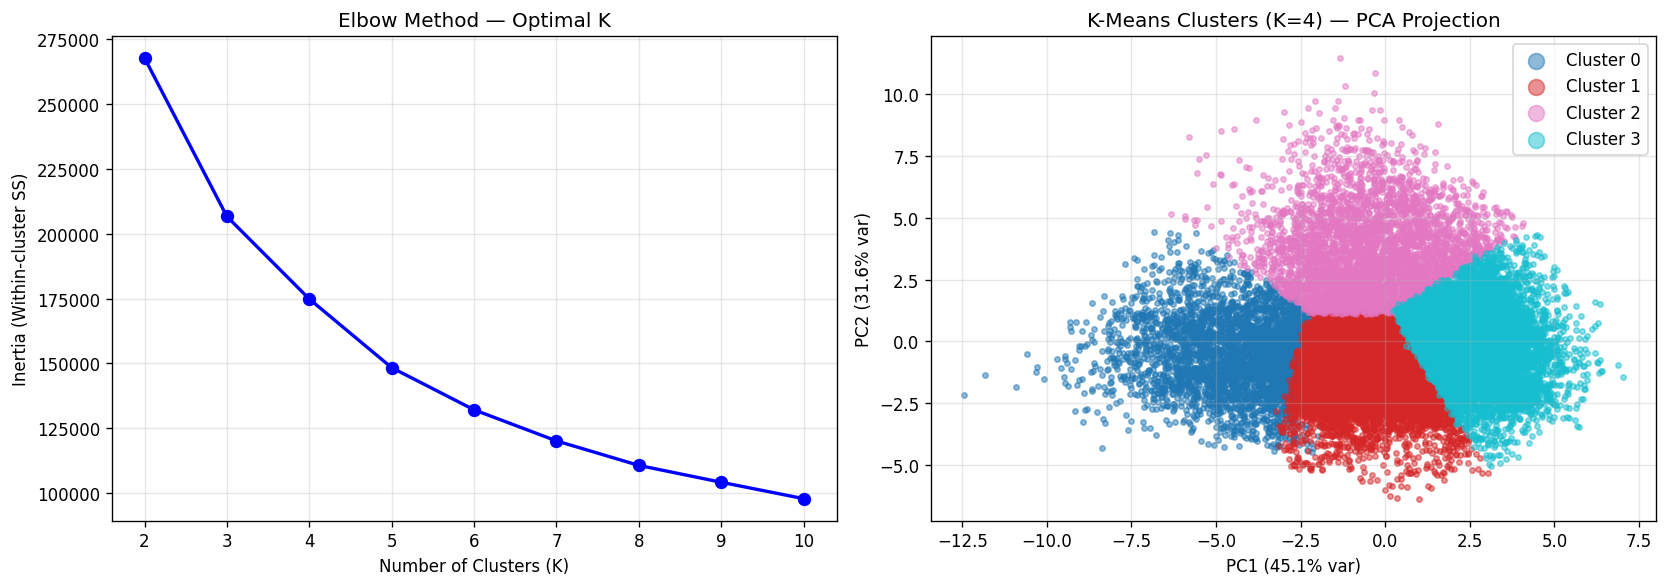


  Cluster Profiles (mean values):


,soybean_yield,growing_season_precipitation_mean,growing_season_solar_radiation_mean,growing_season_snow_water_equivalent_mean,growing_season_maximum_temperature_mean,growing_season_minimum_temperature_mean,growing_season_vapor_pressure_mean
cluster,,,,,,,
0,32.675,2.620,381.319,3.438,22.516,9.422,1179.197
1,43.780,3.666,379.470,0.309,24.360,12.029,1479.015
2,36.118,2.213,405.890,0.082,27.283,12.189,1357.704
3,36.735,3.598,385.972,0.011,27.019,14.533,1734.264



  ✓ K-Means complete. Clusters added to feat dataframe.


In [ ]:
# Counties with similar environmental conditions show similar yield patterns.
print('=' * 65)
print('STEP 5 — K-Means Clustering (County Agro-Climate Profiles)')
print('=' * 65)

# ── Features for clustering (exclude target, IDs, and raw weekly cols) ─
cluster_feature_cols = (
    [f'growing_season_{v}_mean' for v in WEATHER_VAR_NAMES.values()]
  + [f'growing_season_{v}_sum'  for v in WEATHER_VAR_NAMES.values()]
  + [f'{p}_depth_averaged_mean' for p in SOIL_PROPERTY_NAMES.values()]
  + ['county_centroid_latitude', 'county_centroid_longitude',
     'growing_season_diurnal_temperature_range']
)
cluster_feature_cols = [c for c in cluster_feature_cols if c in feat.columns]

X_cluster = feat[cluster_feature_cols].fillna(0).values
scaler_c = StandardScaler()
X_cluster_s = scaler_c.fit_transform(X_cluster)

# ── Elbow method to find optimal K ────────────────────────────
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_s)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].grid(alpha=0.3)

# ── Fit with K=4 (adjust after inspecting elbow plot) ─────────
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
feat['cluster'] = kmeans.fit_predict(X_cluster_s)

# ── PCA for 2D visualization ───────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_s)
colors = cm.tab10(np.linspace(0, 1, K_OPTIMAL))

for k in range(K_OPTIMAL):
    mask = feat['cluster'] == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[colors[k]], label=f'Cluster {k}', alpha=0.5, s=10)
axes[1].set_title(f'K-Means Clusters (K={K_OPTIMAL}) — PCA Projection')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(markerscale=3)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/clustering_results.png', bbox_inches='tight')
plt.show()

# ── Cluster profiles ──────────────────────────────────────────
profile_cols = ['cluster', 'soybean_yield'] + [f'growing_season_{v}_mean' for v in WEATHER_VAR_NAMES.values()]
profile_cols = [c for c in profile_cols if c in feat.columns]
cluster_profile = feat[profile_cols].groupby('cluster').mean().round(3)
print('\n  Cluster Profiles (mean values):')
display(cluster_profile)
print(f'\n  ✓ K-Means complete. Clusters added to feat dataframe.')

## STEP 6 — Model Training (Temporal Cross-Validation)

Models trained from simplest to most complex:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Random Forest
5. XGBoost

In [ ]:
# ── Feature set for modelling ─────────────────────────────────
feature_cols = (
    [f'growing_season_{v}_mean'   for v in WEATHER_VAR_NAMES.values()]
  + [f'growing_season_{v}_sum'    for v in WEATHER_VAR_NAMES.values()]
  + [f'growing_season_{v}_std'    for v in WEATHER_VAR_NAMES.values()]
  + [f'annual_{v}_mean'           for v in WEATHER_VAR_NAMES.values()]
  + [f'{p}_depth_averaged_mean'   for p in SOIL_PROPERTY_NAMES.values()]
  + [f'{p}_topsoil_mean'          for p in SOIL_PROPERTY_NAMES.values()]
  + [f'{new_p}_log1p'             for new_p in PRACTICE_NAMES.values()]
  + ['growing_season_diurnal_temperature_range',
     'growing_season_precipitation_x_solar_radiation',
     'growing_season_vapor_pressure_x_max_temperature',
     'years_since_1980',
     'state_encoded_integer',
     'county_centroid_latitude',
     'county_centroid_longitude',
     'cluster']
)
feature_cols = [c for c in feature_cols if c in feat.columns]
TARGET = 'soybean_yield'

print(f'  Number of features used: {len(feature_cols)}')

# ── Temporal fold definitions ─────────────────────────────────
folds = [
    {'train_max_year': 2013, 'test_year': 2014},
    {'train_max_year': 2014, 'test_year': 2015},
    {'train_max_year': 2015, 'test_year': 2016},
    {'train_max_year': 2016, 'test_year': 2017},
    {'train_max_year': 2017, 'test_year': 2018},
]

# ── Model definitions ─────────────────────────────────────────
MODELS = {
    'Linear Regression'  : LinearRegression(),
    'Ridge (α=1)'        : Ridge(alpha=1.0),
    'Lasso (α=0.1)'      : Lasso(alpha=0.1, max_iter=5000),
    'Random Forest'      : RandomForestRegressor(
                               n_estimators=200, max_depth=10,
                               min_samples_leaf=5, random_state=42,
                               n_jobs=-1),
    'XGBoost'            : xgb.XGBRegressor(
                               n_estimators=300, max_depth=6,
                               learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8, random_state=42,
                               verbosity=0),
}

# ── Training loop ──────────────────────────────────────────────
print('=' * 65)
print('STEP 6 — Training Models (5-Fold Temporal CV)')
print('=' * 65)
print('  Folds: train up to year T, test on year T+1  (T = 2013–2017)')

all_results = {name: [] for name in MODELS}
fold_summaries = []

for fold_num, fold in enumerate(folds, 1):
    train_df = feat[feat['observation_year'] <= fold['train_max_year']]
    test_df  = feat[feat['observation_year'] == fold['test_year']]

    if len(test_df) == 0:
        print(f'  Fold {fold_num}: No test data for {fold["test_year"]}, skipping.')
        continue

    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df[TARGET].values
    X_test  = test_df[feature_cols].fillna(0).values
    y_test  = test_df[TARGET].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    print(f'\n  ── Fold {fold_num}  |  Train ≤ {fold["train_max_year"]}  '
          f'Test = {fold["test_year"]}  '
          f'(n_train={len(X_train):5d}, n_test={len(X_test):4d})')

    fold_row = {'Fold': fold_num, 'Test Year': fold['test_year']}

    for model_name, model in MODELS.items():
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        all_results[model_name].append({'rmse': rmse, 'mae': mae, 'r2': r2})
        fold_row[f'{model_name} RMSE'] = round(rmse, 3)
        fold_row[f'{model_name} R²']   = round(r2, 4)

        print(f'    {model_name:<22} → RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}')

    fold_summaries.append(fold_row)

print('\n Training complete.')

  Number of features used: 46
STEP 6 — Training Models (5-Fold Temporal CV)
  Folds: train up to year T, test on year T+1  (T = 2013–2017)

  ── Fold 1  |  Train ≤ 2013  Test = 2014  (n_train=22650, n_test= 559)
    Linear Regression      → RMSE=7.231  MAE=5.711  R²=0.4170
    Ridge (α=1)            → RMSE=7.225  MAE=5.709  R²=0.4180
    Lasso (α=0.1)          → RMSE=7.313  MAE=5.810  R²=0.4037
    Random Forest          → RMSE=6.890  MAE=5.711  R²=0.4708
    XGBoost                → RMSE=5.621  MAE=4.549  R²=0.6477

  ── Fold 2  |  Train ≤ 2014  Test = 2015  (n_train=23209, n_test= 516)
    Linear Regression      → RMSE=9.212  MAE=7.192  R²=0.0380
    Ridge (α=1)            → RMSE=9.207  MAE=7.179  R²=0.0390
    Lasso (α=0.1)          → RMSE=9.303  MAE=7.261  R²=0.0189
    Random Forest          → RMSE=8.482  MAE=6.780  R²=0.1844
    XGBoost                → RMSE=7.495  MAE=5.969  R²=0.3632

  ── Fold 3  |  Train ≤ 2015  Test = 2016  (n_train=23725, n_test= 549)
    Linear Regression 

## STEP 7 — Model Evaluation & Comparison

STEP 7 — 5-Fold Average Metrics Summary

Model Comparison (sorted by Mean RMSE):


,Model,Mean RMSE,Std RMSE,Mean MAE,Mean R²,Std R²
4,XGBoost,6.648,1.225,5.349,0.4286,0.3309
3,Random Forest,7.813,1.277,6.403,0.2093,0.4530
0,Linear Regression,9.156,1.678,7.486,-0.0751,0.6217
1,Ridge (α=1),9.163,1.671,7.493,-0.0756,0.6181
2,Lasso (α=0.1),9.996,1.675,8.345,-0.2455,0.5881


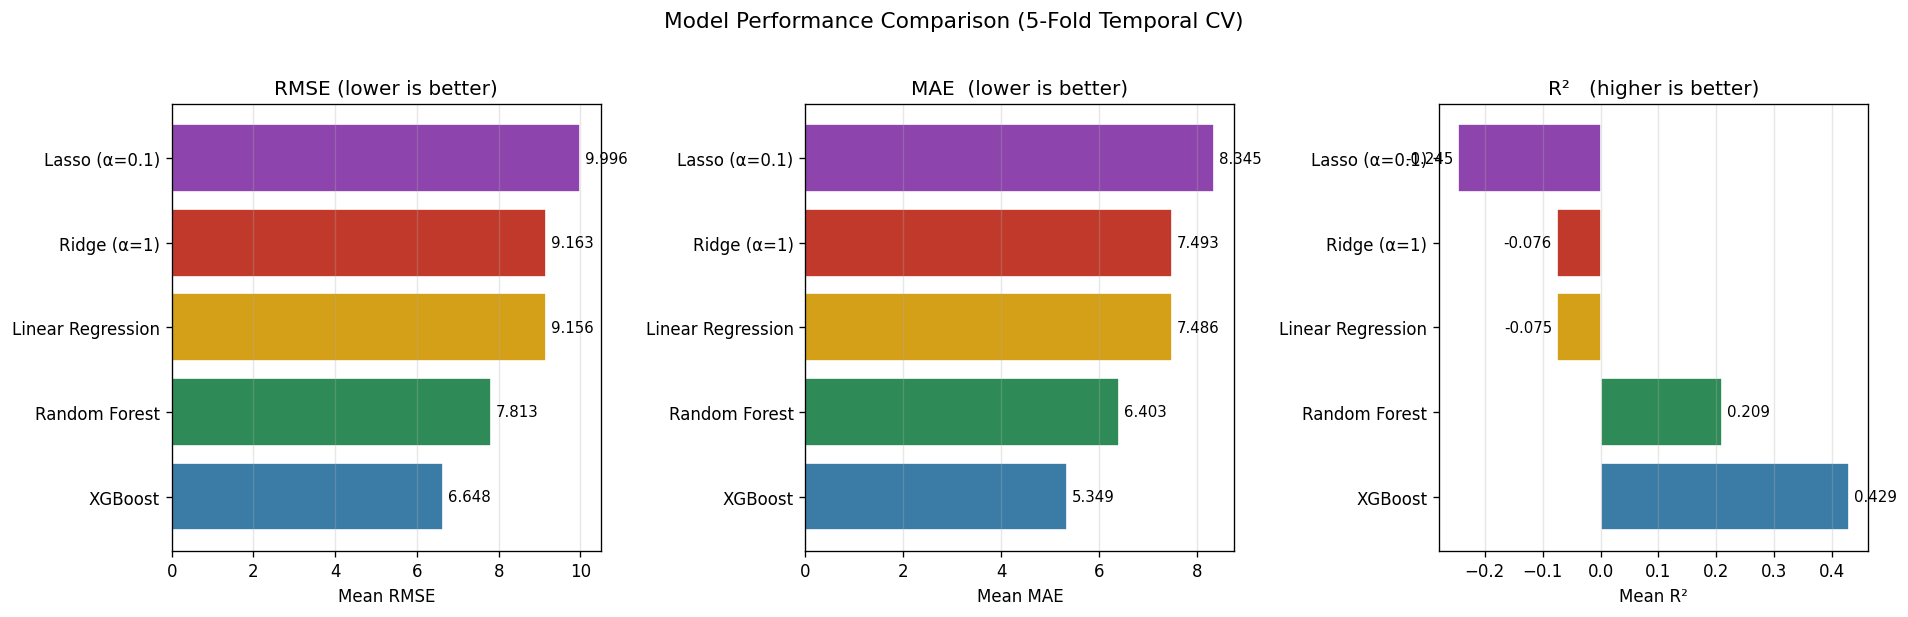

 Comparison chart saved.


In [ ]:
print('=' * 65)
print('STEP 7 — 5-Fold Average Metrics Summary')
print('=' * 65)

summary_rows = []
for model_name, fold_results in all_results.items():
    rmses = [r['rmse'] for r in fold_results]
    maes  = [r['mae']  for r in fold_results]
    r2s   = [r['r2']   for r in fold_results]
    summary_rows.append({
        'Model'        : model_name,
        'Mean RMSE'    : round(np.mean(rmses), 3),
        'Std RMSE'     : round(np.std(rmses),  3),
        'Mean MAE'     : round(np.mean(maes),  3),
        'Mean R²'      : round(np.mean(r2s),   4),
        'Std R²'       : round(np.std(r2s),    4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Mean RMSE')
print('\nModel Comparison (sorted by Mean RMSE):')
display(summary_df)

# ── Comparison bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#3A7CA5', '#2E8B57', '#D4A017', '#C0392B', '#8E44AD']

metrics = [('Mean RMSE', 'RMSE (lower is better)'),
           ('Mean MAE',  'MAE  (lower is better)'),
           ('Mean R²',   'R²   (higher is better)')]

for ax, (metric, label) in zip(axes, metrics):
    vals = summary_df[metric].values
    models = summary_df['Model'].values
    bars = ax.barh(models, vals, color=colors_bar[:len(models)], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(label)
    ax.set_xlabel(metric)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Performance Comparison (5-Fold Temporal CV)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/model_comparison.png', bbox_inches='tight')
plt.show()
print(' Comparison chart saved.')

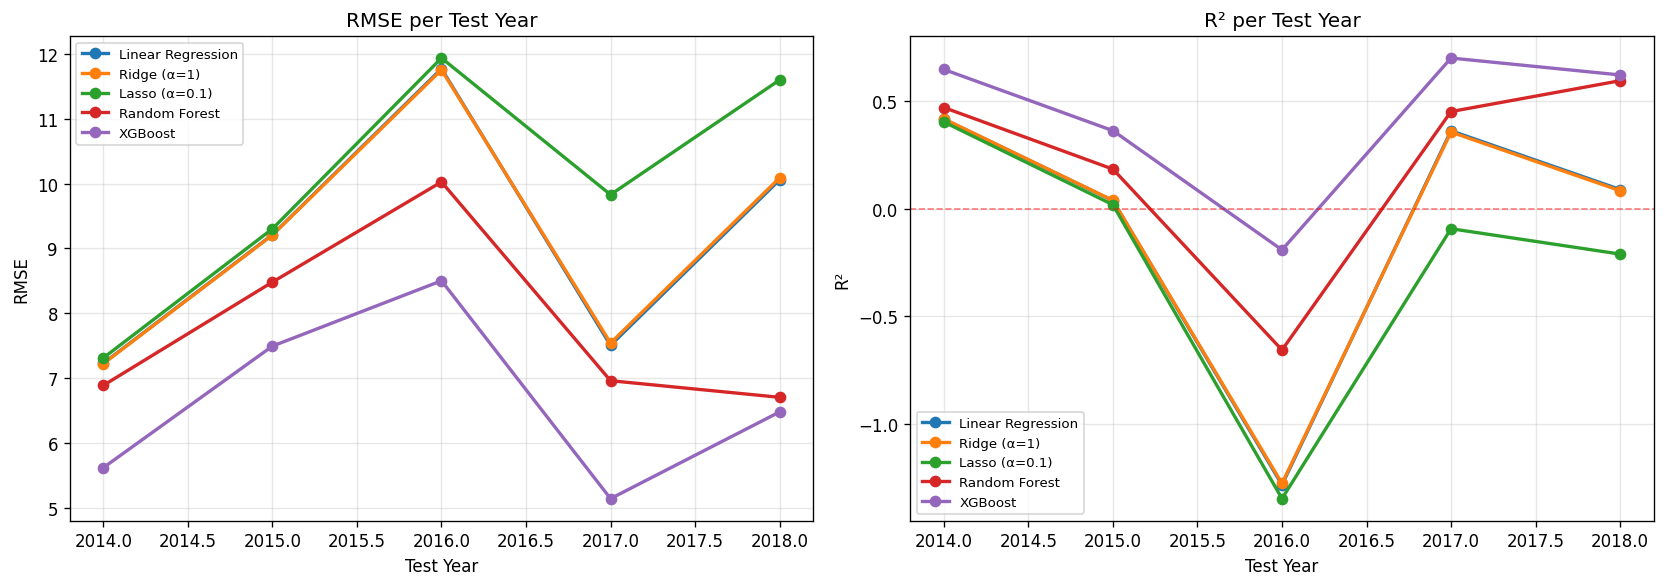

In [ ]:
# ── Per-fold RMSE trend ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_years = [f['test_year'] for f in folds]
for model_name, fold_results in all_results.items():
    if len(fold_results) == len(test_years):
        axes[0].plot(test_years, [r['rmse'] for r in fold_results],
                     marker='o', linewidth=2, label=model_name)
        axes[1].plot(test_years, [r['r2'] for r in fold_results],
                     marker='o', linewidth=2, label=model_name)

axes[0].set_title('RMSE per Test Year')
axes[0].set_xlabel('Test Year')
axes[0].set_ylabel('RMSE')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title('R² per Test Year')
axes[1].set_xlabel('Test Year')
axes[1].set_ylabel('R²')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fold_performance.png', bbox_inches='tight')
plt.show()

## STEP 8 — Feature Importance (Random Forest & XGBoost)
Retrain best models on all data up to 2017 and extract top feature importances.

STEP 8 — Feature Importance Analysis


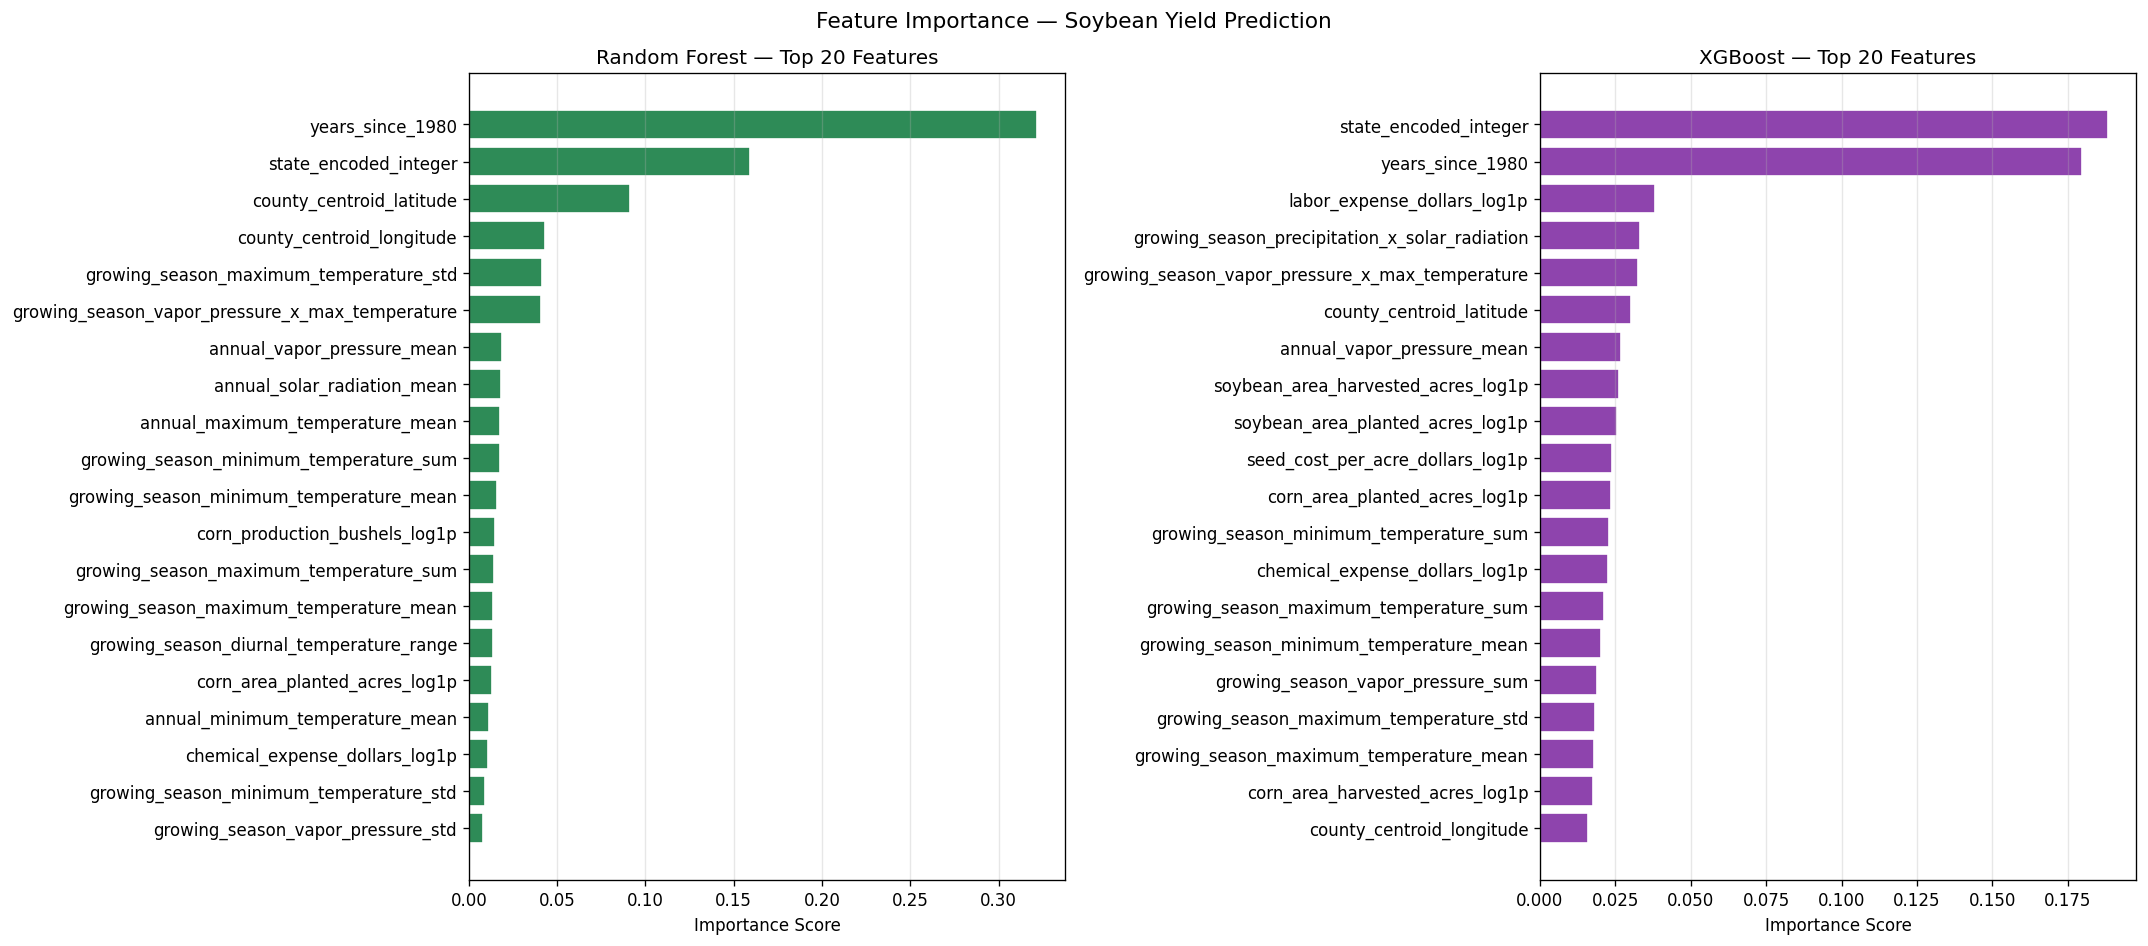


  Top-10 features — Random Forest:


,Importance
years_since_1980,0.321574
state_encoded_integer,0.159433
county_centroid_latitude,0.091519
county_centroid_longitude,0.043297
growing_season_maximum_temperature_std,0.041251
growing_season_vapor_pressure_x_max_temperature,0.040555
annual_vapor_pressure_mean,0.018687
annual_solar_radiation_mean,0.018042
annual_maximum_temperature_mean,0.017845
growing_season_minimum_temperature_sum,0.017712



  Top-10 features — XGBoost:


,Importance
state_encoded_integer,0.188161
years_since_1980,0.179599
labor_expense_dollars_log1p,0.038197
growing_season_precipitation_x_solar_radiation,0.033061
growing_season_vapor_pressure_x_max_temperature,0.032568
county_centroid_latitude,0.030103
annual_vapor_pressure_mean,0.026965
soybean_area_harvested_acres_log1p,0.026270
soybean_area_planted_acres_log1p,0.025534
seed_cost_per_acre_dollars_log1p,0.023924


In [ ]:
print('=' * 65)
print('STEP 8 — Feature Importance Analysis')
print('=' * 65)

# ── Train on full data up to 2017 ─────────────────────────────
train_full = feat[feat['observation_year'] <= 2017]
X_full = train_full[feature_cols].fillna(0).values
y_full = train_full[TARGET].values

scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X_full)

rf_final = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1)
rf_final.fit(X_full_s, y_full)

xgb_final = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)
xgb_final.fit(X_full_s, y_full)

# ── Plot top-20 feature importances ───────────────────────────
TOP_N = 20

def plot_importance(importances, feature_names, title, ax, color):
    indices = np.argsort(importances)[-TOP_N:]
    ax.barh([feature_names[i] for i in indices],
            importances[indices], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_importance(rf_final.feature_importances_, feature_cols,
                f'Random Forest — Top {TOP_N} Features', axes[0], '#2E8B57')
plot_importance(xgb_final.feature_importances_, feature_cols,
                f'XGBoost — Top {TOP_N} Features', axes[1], '#8E44AD')

plt.suptitle('Feature Importance — Soybean Yield Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('/content/feature_importance.png', bbox_inches='tight')
plt.show()

# ── Top-10 printed ────────────────────────────────────────────
rf_top10 = pd.Series(rf_final.feature_importances_, index=feature_cols)\
             .sort_values(ascending=False).head(10)
xgb_top10 = pd.Series(xgb_final.feature_importances_, index=feature_cols)\
              .sort_values(ascending=False).head(10)

print('\n  Top-10 features — Random Forest:')
display(rf_top10.to_frame('Importance'))

print('\n  Top-10 features — XGBoost:')
display(xgb_top10.to_frame('Importance'))

## STEP 9 — Predicted vs. Actual Scatter (Best Model)

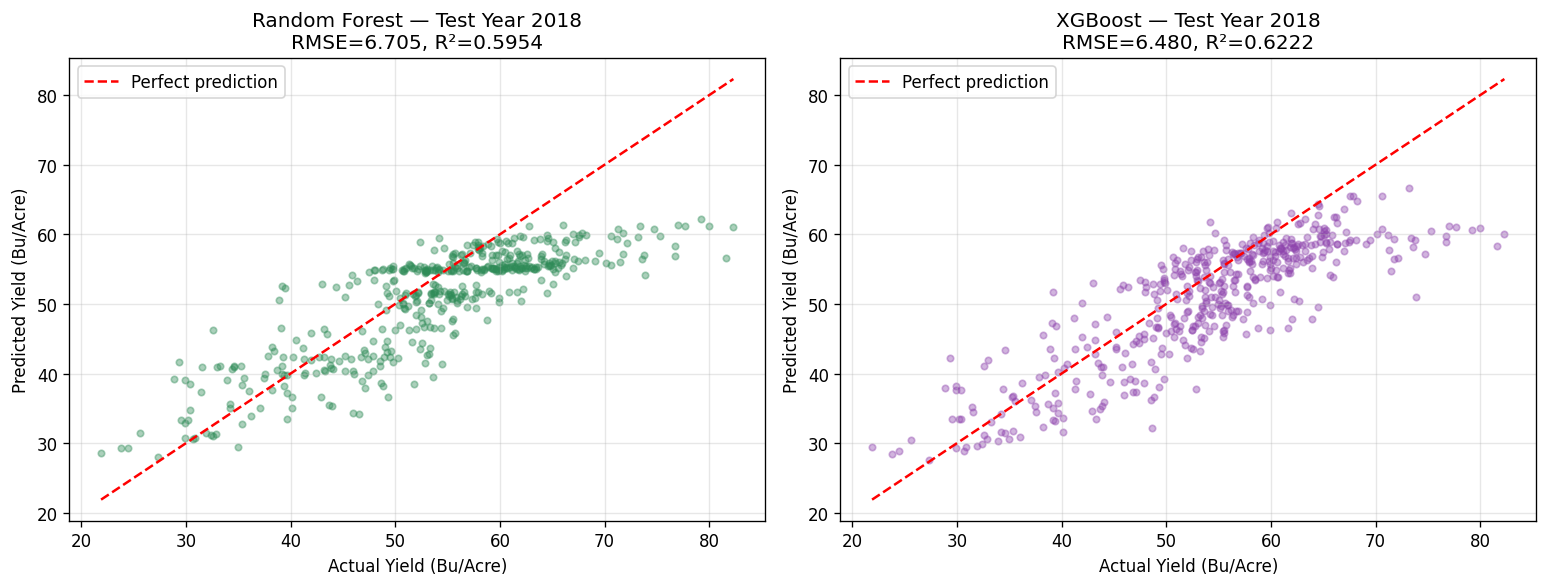

In [ ]:
# ── Use last fold's test set (2018) for scatter plot ──────────
best_fold  = folds[-1]  # train ≤ 2017, test = 2018
train_b    = feat[feat['observation_year'] <= best_fold['train_max_year']]
test_b     = feat[feat['observation_year'] == best_fold['test_year']]

X_train_b  = train_b[feature_cols].fillna(0).values
y_train_b  = train_b[TARGET].values
X_test_b   = test_b[feature_cols].fillna(0).values
y_test_b   = test_b[TARGET].values

scaler_b   = StandardScaler()
X_train_bs = scaler_b.fit_transform(X_train_b)
X_test_bs  = scaler_b.transform(X_test_b)

xgb_plot = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)
xgb_plot.fit(X_train_bs, y_train_b)
y_pred_plot = xgb_plot.predict(X_test_bs)

rf_plot = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1)
rf_plot.fit(X_train_bs, y_train_b)
y_pred_rf_plot = rf_plot.predict(X_test_bs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def scatter_pred_actual(ax, y_true, y_pred, title, color):
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, color=color)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    ax.set_title(f'{title}\nRMSE={rmse:.3f}, R²={r2:.4f}')
    ax.set_xlabel('Actual Yield (Bu/Acre)')
    ax.set_ylabel('Predicted Yield (Bu/Acre)')
    ax.legend()
    ax.grid(alpha=0.3)

scatter_pred_actual(axes[0], y_test_b, y_pred_rf_plot,
                    'Random Forest — Test Year 2018', '#2E8B57')
scatter_pred_actual(axes[1], y_test_b, y_pred_plot,
                    'XGBoost — Test Year 2018', '#8E44AD')

plt.tight_layout()
plt.savefig('/content/predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## STEP 10 — Final Summary & Download All Outputs

In [ ]:
print('=' * 65)
print('PIPELINE COMPLETE — Final Summary')
print('=' * 65)

print(f'\n  Dataset       : {len(feat):,} rows × {feat.shape[1]} columns')
print(f'  Features used : {len(feature_cols)}')
print(f'  Clusters (K)  : {K_OPTIMAL}')
print()

print('  Model Performance (5-Fold Temporal CV):')
display(summary_df)

best_model_row = summary_df.iloc[0]
print(f'\n   Best Model : {best_model_row["Model"]}')
print(f'     Mean RMSE  : {best_model_row["Mean RMSE"]} ± {best_model_row["Std RMSE"]}')
print(f'     Mean R²    : {best_model_row["Mean R²"]} ± {best_model_row["Std R²"]}')

# ── Download all output PNGs ──────────────────────────────────
from google.colab import files
import os

output_files = [
    '/content/soybean_yield_cleaned_engineered.csv',
    '/content/eda_overview.png',
    '/content/clustering_results.png',
    '/content/model_comparison.png',
    '/content/fold_performance.png',
    '/content/feature_importance.png',
    '/content/predicted_vs_actual.png',
]

print('\n  Downloading output files …')
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'    ✓ {f}')
    else:
        print(f'    ✗ Not found: {f}')

print('\n   All done!')

PIPELINE COMPLETE — Final Summary

  Dataset       : 25,304 rows × 449 columns
  Features used : 46
  Clusters (K)  : 4

  Model Performance (5-Fold Temporal CV):


,Model,Mean RMSE,Std RMSE,Mean MAE,Mean R²,Std R²
4,XGBoost,6.648,1.225,5.349,0.4286,0.3309
3,Random Forest,7.813,1.277,6.403,0.2093,0.4530
0,Linear Regression,9.156,1.678,7.486,-0.0751,0.6217
1,Ridge (α=1),9.163,1.671,7.493,-0.0756,0.6181
2,Lasso (α=0.1),9.996,1.675,8.345,-0.2455,0.5881



   Best Model : XGBoost
     Mean RMSE  : 6.648 ± 1.225
     Mean R²    : 0.4286 ± 0.3309



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

    ✓ /content/feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

    ✓ /content/predicted_vs_actual.png

   All done!
